In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt 



rng = np.random.default_rng(42)

n_samples = 2000
n_features = 1000
n_true_factors = 200

true_factors = rng.normal(0,1,size=(n_samples,n_true_factors))
mixing_weights = rng.normal(0,1,size=(n_true_factors,n_features))
X = true_factors @ mixing_weights + rng.normal(0,0.5,size=(n_samples,n_features))

true_coefficients = rng.normal(0,1,size=n_true_factors)
y= true_factors @ true_coefficients + rng.normal(0,5,size=n_samples)

print(f"Xs_shape : {X.shape} (1000 columns , but only {n_true_factors} are truly independent)")

Xs_shape : (2000, 1000) (1000 columns , but only 200 are truly independent)


In [4]:
X_train ,X_test , y_train , y_test = train_test_split(X,y,test_size=.25,random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.fit_transform(X_test)

baseline_model = LinearRegression().fit(x_train_scaled,y_train)
r2_baseline = r2_score(y_test,baseline_model.predict(x_test_scaled))

print(f"LinearRegression on all {X.shape[1]} raw features -> test R^2 = {r2_baseline:.3f}")

LinearRegression on all 1000 raw features -> test R^2 = 0.462


# APPLY PCA 

In [ ]:
pca_full = PCA(random_state=42)
pca_full.fit(x_train_scaled)

cumilative_variance = np.cumsum(pca_full.explained_variance_ratio_)

for n_comp in [50,100,150,200,250,300]:
   print(f"First {n_comp:4d} components explain {cumilative_variance[n_comp-1]:.1%} of total variance")

First   50 components explain 45.4% of total variance
First  100 components explain 73.2% of total variance
First  150 components explain 90.4% of total variance
First  199 components explain 99.8% of total variance
First  200 components explain 99.9% of total variance
First  250 components explain 99.9% of total variance
First  300 components explain 99.9% of total variance


# ScreePlot

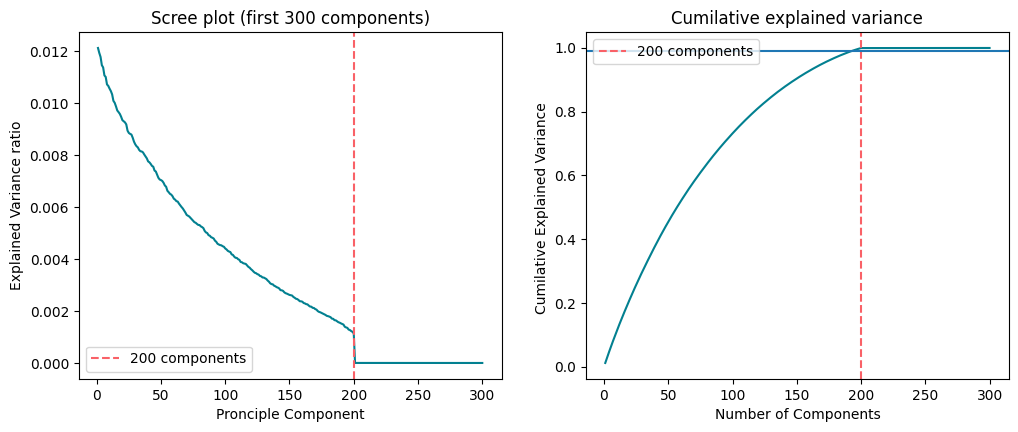

In [12]:
fig,axes = plt.subplots(1,2,figsize=(12,4.5))

axes[0].plot(range(1,301),pca_full.explained_variance_ratio_[:300],color='#028090')
axes[0].axvline(200,color='#F96167', linestyle = "--" , label="200 components")
axes[0].set_xlabel("Pronciple Component")
axes[0].set_ylabel("Explained Variance ratio")
axes[0].set_title("Scree plot (first 300 components)")
axes[0].legend()

axes[1].plot(range(1,301),cumilative_variance[:300],color='#028090')
axes[1].axvline(200,color='#F96167', linestyle = "--" , label="200 components")
axes[1].axhline(.99)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumilative Explained Variance ")
axes[1].set_title("Cumilative explained variance")
axes[1].legend()

In [15]:
results = {}

for n_comp in [50,100,150,200,250,300]:
   pca = PCA(n_components=n_comp,random_state=42)
   X_train_pca = pca.fit_transform(x_train_scaled)
   X_test_pca = pca.fit_transform(x_test_scaled)

   model = LinearRegression().fit(X_train_pca,y_train)
   r2 = r2_score(y_test,model.predict(X_test_pca))
   results[n_comp] = r2
   print(f"PCA with {n_comp:4d} components -> test r^2 = {r2:3f} ")

print(f"for comparison , all {X.shape[1]} raw features -> {results}")

PCA with   50 components -> test r^2 = -0.441983 
PCA with  100 components -> test r^2 = -0.820385 
PCA with  150 components -> test r^2 = -1.007947 
PCA with  200 components -> test r^2 = -1.100836 
PCA with  250 components -> test r^2 = -1.109267 
PCA with  300 components -> test r^2 = -1.108262 
for comparison , all 1000 raw features -> {50: -0.4419830800797666, 100: -0.8203850737079077, 150: -1.0079472914951397, 200: -1.1008355315659957, 250: -1.109267131458334, 300: -1.1082621503092813}
